EuroSAT Deep Learning Pipeline: Training, Optimization, and Edge Deployment
=
This notebook covers:
1. Dataset Preparation & Preprocessing
2. Model Training (ResNet18)
3. Model Conversion (FP32 TFLite & INT8 Quantized TFLite)
4. Performance Benchmarking (Latency & Size)
5. Advanced Evaluation (Precision/Recall, Confusion Matrix)
6. Structured Reporting (CSV/JSON)


# Installations

In [ ]:
import sys
!pip install -U pip

# Uninstall everything to ensure a clean slate and avoid "broken" installations
!pip uninstall -y tensorflow tensorflow-gpu tf-nightly protobuf absl-py litert-torch-nightly torch torchvision torchao

# Install core libraries and LiteRT Nightly
# Ensure tf-nightly is explicitly installed as litert-torch-nightly often depends on it
!pip install torch torchvision torchao tf-nightly litert-torch-nightly

# Ensure reporting and evaluation libraries are present
!pip install scikit-learn seaborn pandas matplotlib

Found existing installation: tf_nightly 2.22.0.dev20260425
Uninstalling tf_nightly-2.22.0.dev20260425:
  Successfully uninstalled tf_nightly-2.22.0.dev20260425
Found existing installation: protobuf 7.34.1
Uninstalling protobuf-7.34.1:
  Successfully uninstalled protobuf-7.34.1
Found existing installation: absl-py 2.4.0
Uninstalling absl-py-2.4.0:
  Successfully uninstalled absl-py-2.4.0
Found existing installation: litert-torch-nightly 0.10.0.dev20260425
Uninstalling litert-torch-nightly-0.10.0.dev20260425:
  Successfully uninstalled litert-torch-nightly-0.10.0.dev20260425
Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Found existing installation: torchao 0.17.0
Uninstalling torchao-0.17.0:
  Successfully uninstalled torchao-0.17.0
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.met

#Dataset Preparation

In [ ]:
import os
import zipfile
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# Mount Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

gdrive_zip_path = '/content/drive/MyDrive/EuroSAT_RGB.zip'
extract_to_dir = '/content/EuroSAT_extracted'

if not os.path.exists(extract_to_dir):
    os.makedirs(extract_to_dir, exist_ok=True)
    with zipfile.ZipFile(gdrive_zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to_dir)

# Identify data directory
data_dir = os.path.join(extract_to_dir, 'EuroSAT_RGB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Loading and Splitting
full_dataset = datasets.ImageFolder(root=data_dir)
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

train_ds.dataset.transform = train_transform
val_ds.dataset.transform = eval_transform
test_ds.dataset.transform = eval_transform

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Model Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(full_dataset.classes)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training Loop (5 Epochs)
for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete.")

Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.


In [ ]:
# Size of the model
def get_model_size(model):
    torch.save(model.state_dict(), "temp.pt")
    size = os.path.getsize("temp.pt")
    os.remove("temp.pt")
    return size

model_size = get_model_size(model)
print(f"Model size: {model_size / 1024 / 1024:.2f} MB")

Model size: 42.72 MB


In [ ]:
import time

model.eval()

with torch.no_grad():
    dummy_input = torch.randn(1, 3, 224, 224, device=device)

    # Warm-up runs
    for _ in range(10):
        _ = model(dummy_input)

    # Measure actual inference time over several iterations
    iterations = 100
    start_time = time.time()
    for _ in range(iterations):
        _ = model(dummy_input)
    avg_latency = (time.time() - start_time) / iterations

print(f"PyTorch Model Latency: {avg_latency:.4f} seconds")

PyTorch Model Latency: 0.0060 seconds


In [ ]:
# Move model to CPU for inference benchmarking
model = model.to("cpu")
device = torch.device("cpu")
print("Model moved to CPU for inference.")

Model moved to CPU for inference.


# Model Conversion

In [ ]:
import os
import copy
import torch
import litert_torch

from litert_torch.quantize.quant_config import QuantConfig
from litert_torch.quantize.pt2e_quantizer import (
    PT2EQuantizer,
    get_symmetric_quantization_config,
)
from torchao.quantization.pt2e.quantize_pt2e import prepare_pt2e, convert_pt2e

model = model.eval().cpu()

sample_inputs = (torch.randn(1, 3, 224, 224),)

# --- Path A: FP32 ---
print("Converting to FP32 TFLite...")
edge_model_fp32 = litert_torch.convert(copy.deepcopy(model), sample_inputs)
edge_model_fp32.export("eurosat_fp32.tflite")

# --- Path B: INT8 / PT2E path ---
print("Starting INT8 PT2E Quantization...")
model_int8 = copy.deepcopy(model).eval().cpu()

# Step 1: Export graph (PyTorch 2.6+ style)
exported_program = torch.export.export(model_int8, sample_inputs).module()

# Step 2: Configure quantizer
pt2e_quantizer = PT2EQuantizer().set_global(
    get_symmetric_quantization_config(is_per_channel=True, is_dynamic=True)
)

# Step 3: Prepare
prepared_model = prepare_pt2e(exported_program, pt2e_quantizer)

with torch.no_grad():
    prepared_model(*sample_inputs)

# Step 4: Convert PT2E graph
quantized_torch_model = convert_pt2e(prepared_model, fold_quantize=False)

# Step 5: Convert to LiteRT
print("Finalizing TFLite Conversion...")
edge_model_int8 = litert_torch.convert(
    quantized_torch_model,
    sample_inputs,
    quant_config=QuantConfig(pt2e_quantizer=pt2e_quantizer),
)
edge_model_int8.export("eurosat_int8.tflite")

# --- Report sizes ---
print("\n" + "=" * 30)
print("SUCCESS: MODELS GENERATED")
print("=" * 30)
for f in ["eurosat_fp32.tflite", "eurosat_int8.tflite"]:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024 * 1024)
        print(f"File: {f:20} | Size: {size:5.2f} MB")

Converting to FP32 TFLite...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

(00:04) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:02)

(00:04) [ DONE] LiteRT-Torch Convert (+00:04)

(00:00) [START] Write Model to eurosat_int8.tflite

(00:00) [ DONE] Write Model to eurosat_int8.tflite (+00:00)


SUCCESS: MODELS GENERATED
File: eurosat_fp32.tflite  | Size: 42.67 MB
File: eurosat_int8.tflite  | Size: 10.75 MB


# Benchmarking & Reporting

In [ ]:
import time
import numpy as np
import os
import tensorflow as tf
from ai_edge_litert.interpreter import Interpreter

# Creating a Benchmark Report on the FP32 and INT8
def benchmark_tflite(model_path, iterations=100):
    interpreter = Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_index = interpreter.get_input_details()[0]["index"]

    dummy_input = np.random.randn(1, 3, 224, 224).astype(np.float32)

    start_time = time.time()
    for _ in range(iterations):
        interpreter.set_tensor(input_index, dummy_input)
        interpreter.invoke()
    avg_latency = (time.time() - start_time) / iterations

    file_size = os.path.getsize(model_path) / (1024 * 1024) # MB
    return avg_latency, file_size

fp32_latency, fp32_size = benchmark_tflite("eurosat_fp32.tflite")
int8_latency, int8_size = benchmark_tflite("eurosat_int8.tflite")

print(f"\n[BENCHMARK REPORT]")
print(f"FP32 Model -> Latency: {fp32_latency:.4f}s | Size: {fp32_size:.2f} MB")
print(f"INT8 Model -> Latency: {int8_latency:.4f}s | Size: {int8_size:.2f} MB")


[BENCHMARK REPORT]
FP32 Model -> Latency: 0.0150s | Size: 42.67 MB
INT8 Model -> Latency: 0.0051s | Size: 10.75 MB


# Comprehensive Evaluation


Detailed Evaluation:
                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       300
              Forest       0.99      1.00      0.99       297
HerbaceousVegetation       0.98      0.98      0.98       302
             Highway       0.98      0.97      0.98       269
          Industrial       0.99      0.99      0.99       257
             Pasture       0.95      0.97      0.96       187
       PermanentCrop       0.98      0.96      0.97       254
         Residential       0.99      1.00      0.99       314
               River       0.99      0.97      0.98       245
             SeaLake       0.99      1.00      0.99       275

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700



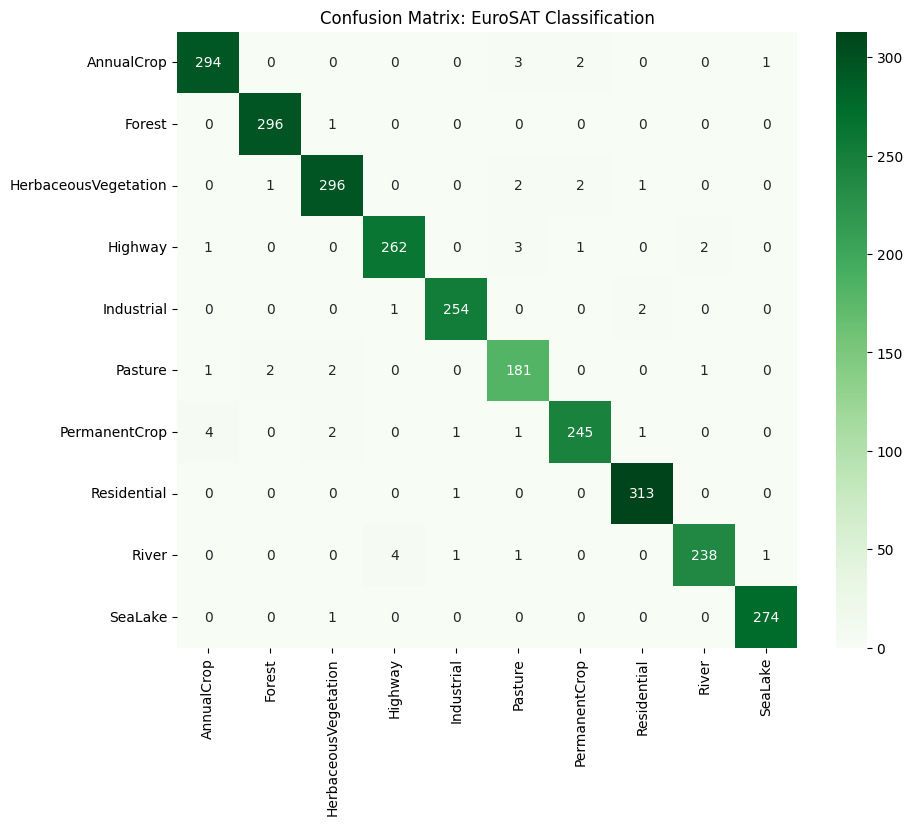

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def evaluate_and_report(model, loader, class_names):
    model.to(device).eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    # Save predictions to CSV for reporting
    df_results = pd.DataFrame({'True': all_labels, 'Pred': all_preds})
    df_results.to_csv("prediction_logs.csv", index=False)

    # Visual Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names, cmap='Greens')
    plt.title("Confusion Matrix: EuroSAT Classification")
    plt.savefig("confusion_matrix.png")

    print("\nDetailed Evaluation:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_and_report(model, test_loader, full_dataset.classes)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:460: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


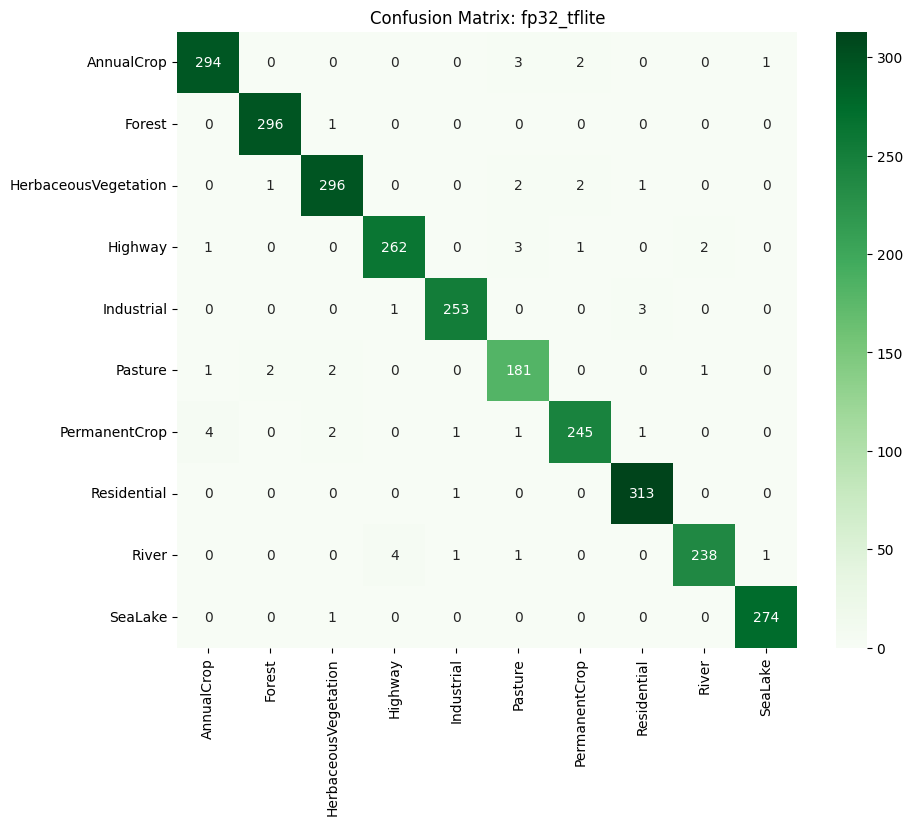


Detailed Evaluation for fp32_tflite:
                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       300
              Forest       0.99      1.00      0.99       297
HerbaceousVegetation       0.98      0.98      0.98       302
             Highway       0.98      0.97      0.98       269
          Industrial       0.99      0.98      0.99       257
             Pasture       0.95      0.97      0.96       187
       PermanentCrop       0.98      0.96      0.97       254
         Residential       0.98      1.00      0.99       314
               River       0.99      0.97      0.98       245
             SeaLake       0.99      1.00      0.99       275

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700



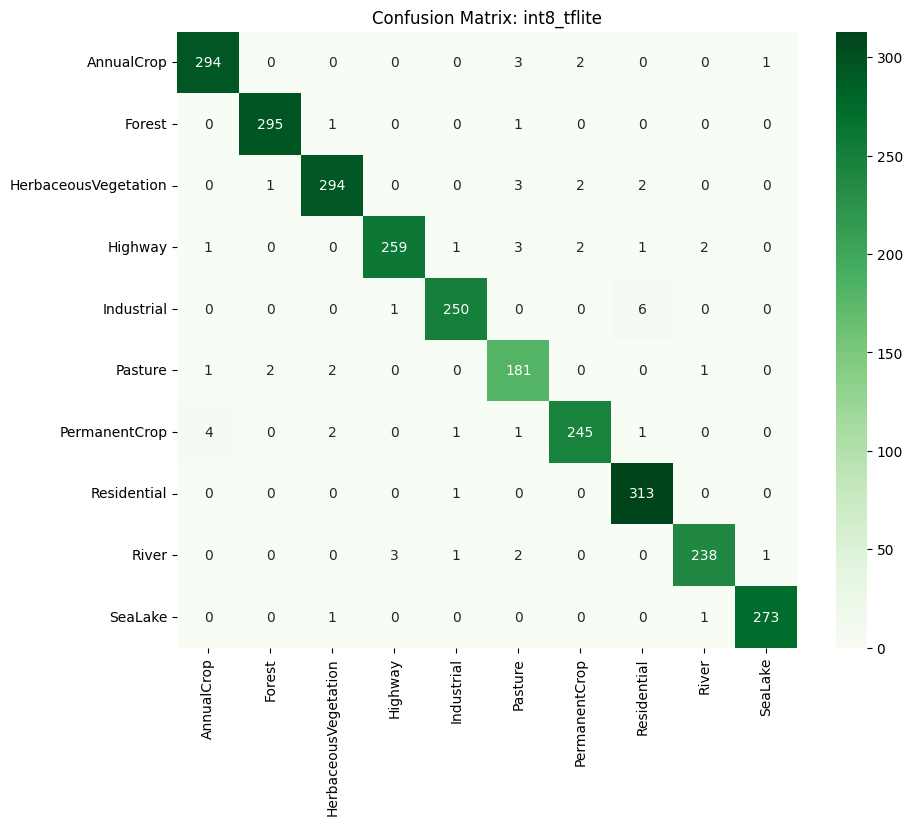


Detailed Evaluation for int8_tflite:
                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       300
              Forest       0.99      0.99      0.99       297
HerbaceousVegetation       0.98      0.97      0.98       302
             Highway       0.98      0.96      0.97       269
          Industrial       0.98      0.97      0.98       257
             Pasture       0.93      0.97      0.95       187
       PermanentCrop       0.98      0.96      0.97       254
         Residential       0.97      1.00      0.98       314
               River       0.98      0.97      0.98       245
             SeaLake       0.99      0.99      0.99       275

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700



In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = full_dataset.classes

# Load interpreters
fp32_interpreter = tf.lite.Interpreter(model_path="eurosat_fp32.tflite")
fp32_interpreter.allocate_tensors()
fp32_input = fp32_interpreter.get_input_details()
fp32_output = fp32_interpreter.get_output_details()

int8_interpreter = tf.lite.Interpreter(model_path="eurosat_int8.tflite")
int8_interpreter.allocate_tensors()
int8_input = int8_interpreter.get_input_details()
int8_output = int8_interpreter.get_output_details()

def run_tflite(interpreter, input_details, output_details, x):
    input_dtype = input_details[0]["dtype"]

    if input_dtype == np.int8 or input_dtype == np.uint8:
        scale, zero_point = input_details[0]["quantization"]
        x = x / scale + zero_point
        if input_dtype == np.int8:
            x = np.clip(np.round(x), -128, 127).astype(np.int8)
        else:
            x = np.clip(np.round(x), 0, 255).astype(np.uint8)
    else:
        x = x.astype(np.float32)

    interpreter.set_tensor(input_details[0]["index"], x)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]["index"])

    output_dtype = output_details[0]["dtype"]
    if output_dtype == np.int8 or output_dtype == np.uint8:
        scale, zero_point = output_details[0]["quantization"]
        out = scale * (out.astype(np.float32) - zero_point)
    else:
        out = out.astype(np.float32)

    return out

def evaluate_tflite_model(interpreter, input_details, output_details, loader, class_names, model_name):
    all_preds, all_labels = [], []

    for images, labels in loader:
        # images come as PyTorch tensors [B, C, H, W]
        images_np = images.cpu().numpy().astype(np.float32)

        for i in range(images_np.shape[0]):
            x = np.expand_dims(images_np[i], axis=0)   # [1, C, H, W]
            out = run_tflite(interpreter, input_details, output_details, x)
            pred = int(np.argmax(out[0]))

            all_preds.append(pred)
            all_labels.append(int(labels[i].item()))

    # Save CSV
    df_results = pd.DataFrame({
        "True": all_labels,
        "Pred": all_preds
    })
    df_results.to_csv(f"{model_name}_prediction_logs.csv", index=False)

    # Confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix(all_labels, all_preds),
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Greens"
    )
    plt.title(f"Confusion Matrix: {model_name}")
    plt.savefig(f"{model_name}_confusion_matrix.png")
    plt.show()

    print(f"\nDetailed Evaluation for {model_name}:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# Evaluate both
evaluate_tflite_model(fp32_interpreter, fp32_input, fp32_output, test_loader, class_names, "fp32_tflite")
evaluate_tflite_model(int8_interpreter, int8_input, int8_output, test_loader, class_names, "int8_tflite")

# StreamLit

In [ ]:
!pip install streamlit pyngrok

In [ ]:
!pkill -f streamlit

In [ ]:
import json

preprocess_config = {
    "image_size": 224,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225]
}

with open("preprocess_config.json", "w") as f:
    json.dump(preprocess_config, f)

print("Saved preprocess_config.json")

Saved preprocess_config.json


In [ ]:
get_ipython().system_raw("streamlit run streamlit_app.py --server.port 8501 &")

In [ ]:
%%writefile streamlit_app.py
import numpy as np
import streamlit as st
from PIL import Image
import tensorflow as tf
import time

st.set_page_config(page_title="EuroSAT TFLite Comparison", layout="centered")
st.title("EuroSAT FP32 vs INT8 Comparison")

class_names = [
    "AnnualCrop", "Forest", "HerbaceousVegetation",
    "Highway", "Industrial", "Pasture",
    "PermanentCrop", "Residential", "River", "SeaLake"
]

# -------------------------
# Load both models
# -------------------------
def load_model(path):
    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()
    return interpreter

fp32_model = load_model("eurosat_fp32.tflite")
int8_model = load_model("eurosat_int8.tflite")

fp32_input = fp32_model.get_input_details()
fp32_output = fp32_model.get_output_details()

int8_input = int8_model.get_input_details()
int8_output = int8_model.get_output_details()

st.write("FP32 expects:", fp32_input[0]["shape"])
st.write("INT8 expects:", int8_input[0]["shape"])

# -------------------------
# Preprocess (NCHW)
# -------------------------
def preprocess(image):
    image = image.resize((224, 224))
    img = np.array(image).astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = (img - mean) / std

    img = np.transpose(img, (2, 0, 1))   # [C, H, W]
    img = np.expand_dims(img, axis=0)     # [1, C, H, W]

    return img

# -------------------------
# Run FP32
# -------------------------
def run_fp32(image):
    x = preprocess(image).astype(np.float32)

    fp32_model.set_tensor(fp32_input[0]["index"], x)

    start = time.perf_counter()
    fp32_model.invoke()
    t = (time.perf_counter() - start) * 1000

    out = fp32_model.get_tensor(fp32_output[0]["index"])[0]
    probs = np.exp(out) / np.sum(np.exp(out))
    pred = np.argmax(probs)

    return pred, probs, t

# -------------------------
# Run INT8
# -------------------------
def run_int8(image):
    x = preprocess(image)

    input_dtype = int8_input[0]["dtype"]

    # Only quantize input if the model actually expects int8/uint8
    if input_dtype == np.int8 or input_dtype == np.uint8:
        scale, zero_point = int8_input[0]["quantization"]
        x = x / scale + zero_point

        if input_dtype == np.int8:
            x = np.clip(np.round(x), -128, 127).astype(np.int8)
        else:
            x = np.clip(np.round(x), 0, 255).astype(np.uint8)
    else:
        x = x.astype(np.float32)

    int8_model.set_tensor(int8_input[0]["index"], x)

    start = time.perf_counter()
    int8_model.invoke()
    t = (time.perf_counter() - start) * 1000

    out = int8_model.get_tensor(int8_output[0]["index"])[0]

    output_dtype = int8_output[0]["dtype"]
    if output_dtype == np.int8 or output_dtype == np.uint8:
        scale, zero_point = int8_output[0]["quantization"]
        out = scale * (out.astype(np.float32) - zero_point)
    else:
        out = out.astype(np.float32)

    probs = np.exp(out - np.max(out)) / np.sum(np.exp(out - np.max(out)))
    pred = np.argmax(probs)

    return pred, probs, t
# -------------------------
# UI
# -------------------------
uploaded_file = st.file_uploader("Upload image", type=["jpg", "jpeg", "png"])

if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, use_container_width=True)

    if st.button("Run comparison"):
        try:
            p1, probs1, t1 = run_fp32(image)
            p2, probs2, t2 = run_int8(image)

            st.subheader("Results")

            col1, col2 = st.columns(2)

            with col1:
                st.markdown("### FP32")
                st.write("Prediction:", class_names[p1])
                st.write(f"Time: {t1:.2f} ms")

            with col2:
                st.markdown("### INT8")
                st.write("Prediction:", class_names[p2])
                st.write(f"Time: {t2:.2f} ms")

        except Exception as e:
            st.error(f"Error: {e}")

Overwriting streamlit_app.py


In [ ]:
import getpass
from pyngrok import ngrok, conf

print("Enter your authtoken, which can be copied from https://dashboard.ngrok.com/get-started/your-authtoken")
conf.get_default().auth_token = getpass.getpass()

# 1. Close all existing tunnels
for t in ngrok.get_tunnels():
    ngrok.disconnect(t.public_url)

# 2. Kill ngrok process (important)
ngrok.kill()

# 3. Start ONE tunnel
public_url = ngrok.connect(8501)
print("Streamlit URL:", public_url)


Enter your authtoken, which can be copied from https://dashboard.ngrok.com/get-started/your-authtoken
··········


Streamlit URL: NgrokTunnel: "https://fondly-elf-untagged.ngrok-free.dev" -> "http://localhost:8501"
